# iToF / Structured-Light Fusion Pipeline 

Calibration and depth fusion for a combined indirect Time-of-Flight (iToF) and Structured Light (SL) approach.
Based on:
- **Microsoft-Paper** – Godbaz et al. 2025 (Microsoft): dot calibration (4.1), 1-D dot trails, consistency error, active brightness trail (4.2)
- **Agresti** – Agresti & Zanuttigh, ECCV 2018: maximum likelihood depth fusion (eq. 16/17)


All heavy lifting lives in `dot_calibration.py`, `calibrate.py`
and `approaches.py`. So this notebook only orchestrates and visualizes.

In [1]:
from dot_calibration import DotCalibration
import approaches
import calibrate
import os
import numpy as np
from pathlib import Path
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import matplotlib.pyplot as plt

dotCal = DotCalibration()

# ── Camera / data selection / presets in calibrate.py
CAMERA = "SchmersalReal"          # "OnSemi" (Simulation) or "Schmersal" (Simulation) or "SchmersalReal" (First real measurement)
cfg     = calibrate.CAMERAS[CAMERA]
sl_cal  = cfg["sl_cal"]
tof_cal = cfg["tof_cal"]
K       = cfg["K"]          
CAL_BLOB_PARAMS = cfg["cal_blob"]
TOF_SAMPLE      = cfg.get("tof_sample")   # how to read ToF depth at a dot (see calibrate.CAMERAS)

K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

SUBPIXEL_MODE = "GPR"      # paper: LoG + GPR ("geometricCenter" as fallback)
TRACK_IN_TX_SPACE = False  # True: re-track in transmitter space (Godbaz 4.1)
BASELINE_OUTLIER_SIGMA = 3.0  # Godbaz: outlier-ray removal before the final Baseline fit
MIN_TRACK_POINTS = 3       # low-confidence invalidation: min distances per dot line
TRAIL_Z_MIN = 0.35          # trails run from here to infinity [m] (Godbaz: ~30 cm)

calibration_figures = []   # list of (name, fig)
print("Setup complete.")

Setup complete.


## Statistical Outlier Removal (CloudCompare-style)

Filters every point cloud the notebook loads, exactly the way CloudCompare's *SOR
filter* does: a point is rejected when the mean distance to its `SOR_K` nearest
neighbours exceeds `mean + SOR_NSIGMA · std` of that quantity over the whole cloud.
Defaults are CloudCompare's own — **6 points, nSigma 1.00**.

The `.pcd` files on disk are never modified. Each load is served from a temporary
copy in which the rejected points are NaN'd; the copy is deleted straight after it
has been read. `SOR_ENABLED = False` restores the raw behaviour, and every cache
file carries `SOR_TAG`, so filtered and unfiltered results can coexist.


In [39]:
# ── Statistical Outlier Removal (CloudCompare's SOR filter) ──────────────────
# For every point: the mean distance to its SOR_K nearest neighbours. A point is
# rejected when that mean exceeds   mean(all) + SOR_NSIGMA · std(all)   — exactly
# what CloudCompare does, and SOR_K = 6 / SOR_NSIGMA = 1.00 are its defaults.
#
# The PCDs on disk are NEVER touched. Every load is served from a temporary copy
# in which the rejected points are NaN'd, and that copy is deleted again as soon
# as it has been read (the source tree is ~93 GB — caching it would mirror it).
# Points are NaN'd rather than dropped because the clouds are organised (640×480)
# and load_tof_pcd only builds points_map / depth_map / intensity_map while
# WIDTH·HEIGHT == POINTS.
#
# Geometry only: grayValue is left alone, so the active-brightness EXRs and
# approach 3's dot detection see exactly the same image as before. Only the
# iToF depth that approaches 1 and 2 consume is filtered.
import atexit
import itertools
import shutil
import sys
import tempfile
import time
from scipy.spatial import cKDTree

SOR_ENABLED   = True    # False → everything runs on the raw clouds, as before
SOR_K         = 6    # CloudCompare "points to use for mean distance estimation"
SOR_NSIGMA    = 0.4    # CloudCompare "standard deviation multiplier"
SOR_KEEP_TEMP = False   # True → keep the filtered clouds until the kernel exits
SOR_VERBOSE   = False   # True → one line per filtered file

# Goes into every cache filename, so filtered and unfiltered results can never be
# mixed up and can be compared by flipping SOR_ENABLED.
SOR_TAG = f"_sor{SOR_K}-{SOR_NSIGMA:.2f}" if SOR_ENABLED else ""

# The repo's PCD header parser, reused read-only (removePCDoutliers.py is not modified).
_repo_root = Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import removePCDoutliers as _rpo

# Probe the first calibration cloud — the same files the calibration below reads.
_sor_probe = sorted(cfg["tof_cal"].glob(cfg.get("pcd_glob", "ToF_*m.pcd")))
SOR_PROBE_PCD = _sor_probe[0] if _sor_probe else Path("/nonexistent.pcd")


def _sor_cleanup():
    # Only the process that made the directory may remove it — a forked sweep
    # worker exiting must not delete the tree the parent is still using.
    if os.getpid() == _SOR_OWNER_PID:
        shutil.rmtree(SOR_TMPDIR, ignore_errors=True)


if "SOR_TMPDIR" not in globals() or not Path(SOR_TMPDIR).is_dir():
    SOR_TMPDIR = Path(tempfile.mkdtemp(prefix="sor_pcd_"))
    _SOR_OWNER_PID = os.getpid()
    atexit.register(_sor_cleanup)

_sor_counter = itertools.count()
_sor_warned = set()


def _sor_warn_once(src, why):
    if why not in _sor_warned:
        _sor_warned.add(why)
        print(f"  [sor] not filtered ({why}) — e.g. {Path(src).name}; passing the source through")


def sor_keep_mask(xyz, k=None, nsigma=None, z_range=None):
    """CloudCompare's statistical outlier removal.

    `xyz` is (N, 3) in metres. Returns (keep, threshold, n_valid): a boolean mask
    over the rows, the rejection threshold on the mean-kNN distance [m], and how
    many points carried a ToF return at all.

    Pixels without a return are excluded from the neighbour statistics and come
    back as not-kept: the sensor writes them as exactly (0, 0, 0), and a pile of
    ~10^5 coincident points at the origin would otherwise have zero neighbour
    distance and pull the mean far below the real surface spacing. The gate is
    the same one load_tof_pcd applies (DotCalibration.VALID_Z_RANGE), so no point
    is dropped here that the pipeline would have used.
    """
    k = int(SOR_K if k is None else k)
    nsigma = float(SOR_NSIGMA if nsigma is None else nsigma)
    z_lo, z_hi = DotCalibration.VALID_Z_RANGE if z_range is None else z_range

    xyz = np.asarray(xyz, dtype=np.float64)
    valid = (np.isfinite(xyz).all(axis=1)
             & np.any(xyz != 0.0, axis=1)
             & (xyz[:, 2] >= z_lo) & (xyz[:, 2] <= z_hi))
    keep = np.zeros(len(xyz), dtype=bool)
    idx = np.flatnonzero(valid)
    if idx.size <= k + 1:                      # too few points to say anything
        keep[idx] = True
        return keep, float("inf"), int(idx.size)

    pts = xyz[idx]
    # k + 1 because the query point matches itself at distance 0; dropping that
    # column leaves exactly k neighbours, as CloudCompare counts them.
    d, _ = cKDTree(pts).query(pts, k=k + 1, workers=1)   # workers=1: a forked
    mean_d = d[:, 1:].mean(axis=1)                       # sweep may already be parallel
    thr = float(mean_d.mean() + nsigma * mean_d.std())
    keep[idx] = mean_d <= thr
    return keep, thr, int(idx.size)


def sor_pcd_to_temp(src, unit_scale=0.001):
    """Write a SOR-filtered copy of `src` into SOR_TMPDIR and return its path.

    `src` is only ever read. The header is copied through byte for byte — the
    point count does not change, so WIDTH/HEIGHT stay correct and the copy is
    still an organised cloud. Returns `src` itself when the file cannot be
    filtered in place (ascii, binary_compressed, no xyz).
    """
    src = Path(src)
    raw = src.read_bytes()
    try:
        hdr, header_len, _ = _rpo.parse_header(raw)
        dtype = _rpo.build_dtype(hdr)[0]
    except Exception as exc:                                    # noqa: BLE001
        _sor_warn_once(src, f"header not parsable: {type(exc).__name__}")
        return src
    if hdr.get("DATA", "").split()[0].lower() != "binary":
        _sor_warn_once(src, f"DATA {hdr.get('DATA')!r}, only binary is filtered in place")
        return src
    if not all(f in dtype.names for f in ("x", "y", "z")):
        _sor_warn_once(src, "no x/y/z fields")
        return src

    npts = int(hdr["POINTS"]) if "POINTS" in hdr else int(hdr["WIDTH"]) * int(hdr["HEIGHT"])
    arr = np.frombuffer(raw, dtype=dtype, count=npts, offset=header_len).copy()
    xyz = np.stack([arr["x"], arr["y"], arr["z"]], axis=1).astype(np.float64) * unit_scale

    keep, thr, n_valid = sor_keep_mask(xyz)
    drop = ~keep
    for f in ("x", "y", "z", "rad", "distZ"):      # geometry only — grayValue stays
        if f in dtype.names and np.issubdtype(dtype[f], np.floating):
            arr[f][drop] = np.nan

    dst = SOR_TMPDIR / f"{src.stem}_p{os.getpid()}_{next(_sor_counter)}.pcd"
    with open(dst, "wb") as fh:
        fh.write(raw[:header_len])
        fh.write(arr.tobytes())
    if SOR_VERBOSE:
        n_kept = int(keep.sum())
        print(f"  [sor] {src.name}: {n_valid} valid → {n_kept} kept "
              f"({100.0 * (n_valid - n_kept) / max(n_valid, 1):.1f}% rejected, "
              f"thr {thr * 1e3:.2f} mm)")
    return dst


# ── The hook: every PCD the notebook reads goes through load_tof_pcd ─────────
# the calibration back-projection (cell 7), the Step A spot check, and
# approaches.common_setup inside the sweep. Patching this one method covers all
# of them, and the fork-based worker pool inherits the patch.
if "_sor_orig_load_tof_pcd" not in globals():
    _sor_orig_load_tof_pcd = DotCalibration.load_tof_pcd


def _sor_load_tof_pcd(self, pcd_path, *args, **kwargs):
    if not SOR_ENABLED:
        return _sor_orig_load_tof_pcd(self, pcd_path, *args, **kwargs)
    unit_scale = kwargs.get("unit_scale", args[0] if args else 0.001)
    tmp = Path(sor_pcd_to_temp(pcd_path, unit_scale=unit_scale))
    try:
        return _sor_orig_load_tof_pcd(self, str(tmp), *args, **kwargs)
    finally:
        if not SOR_KEEP_TEMP and tmp != Path(pcd_path):
            tmp.unlink(missing_ok=True)


DotCalibration.load_tof_pcd = _sor_load_tof_pcd

# ── Probe one frame, so the aggressiveness of the setting is visible up front ─
if not SOR_ENABLED:
    print("SOR disabled — the pipeline reads the raw clouds.")
elif not SOR_PROBE_PCD.exists():
    print(f"SOR active ({SOR_K} pts, {SOR_NSIGMA:.2f} σ) — probe not found: {SOR_PROBE_PCD}")
else:
    _raw = SOR_PROBE_PCD.read_bytes()
    _hdr, _hl, _ = _rpo.parse_header(_raw)
    _dty = _rpo.build_dtype(_hdr)[0]
    _n = int(_hdr["POINTS"])
    _a = np.frombuffer(_raw, dtype=_dty, count=_n, offset=_hl)
    _xyz = np.stack([_a["x"], _a["y"], _a["z"]], axis=1).astype(np.float64) * 0.001
    _t0 = time.time()
    _keep, _thr, _nv = sor_keep_mask(_xyz)
    _el = time.time() - _t0
    _tmp = Path(sor_pcd_to_temp(SOR_PROBE_PCD))
    _kept = int(_keep.sum())
    print(f"SOR active: {SOR_K} neighbours, nSigma = {SOR_NSIGMA:.2f}   (cache tag '{SOR_TAG}')")
    print(f"  probe {SOR_PROBE_PCD.parent.name}/{SOR_PROBE_PCD.name}: {_n} points, "
          f"{_nv} with a ToF return")
    print(f"  kept {_kept}, rejected {_nv - _kept} "
          f"({100.0 * (_nv - _kept) / max(_nv, 1):.1f}% of the valid points)")
    print(f"  max mean-{SOR_K}NN distance = {_thr * 1e3:.3f} mm   |   {_el:.2f} s per cloud")
    print(f"  source {SOR_PROBE_PCD.stat().st_size / 1e6:.1f} MB (untouched)  →  "
          f"temp {_tmp.stat().st_size / 1e6:.1f} MB")
    _tmp.unlink(missing_ok=True)
print(f"temp clouds: {SOR_TMPDIR}  (deleted when the kernel exits)")


SOR active: 6 neighbours, nSigma = 0.40   (cache tag '_sor6-0.40')
  probe ToF/Pos0.pcd: 307200 points, 298673 with a ToF return
  kept 291531, rejected 7142 (2.4% of the valid points)
  max mean-6NN distance = 7.104 mm   |   0.45 s per cloud
  source 14.7 MB (untouched)  →  temp 14.7 MB
temp clouds: /tmp/sor_pcd_1nuh4298  (deleted when the kernel exits)


## Calibration Steps 1–2: Dot Detection, Subpixel Localisation & Tracking

LoG blob detection on each calibration SL image, followed by GPR
(Godbaz 4.1: LoG finds the area near the peak, a Gaussian-process model of the intensity
map is searched for the subpixel location). No fixed grid is assumed.

Stable IDs are then assigned by tracking each dot across the calibration distances with
a nearest-neighbor search; dots may enter/leave FOV between distances.

Calibration distances: [0.402, 0.439, 0.486, 0.545, 0.621, 0.72, 0.857, 1.059, 1.385, 2.0]
  Processing Pos0.exr …


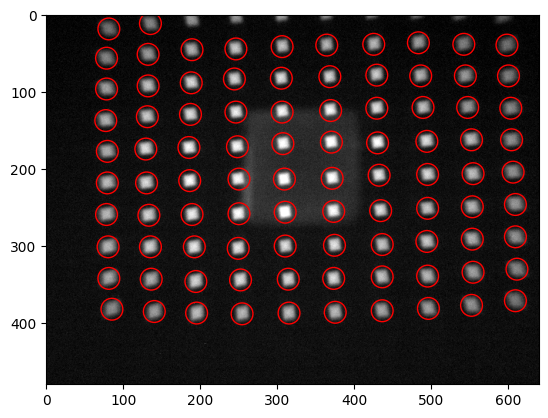

  Processing Pos1.exr …


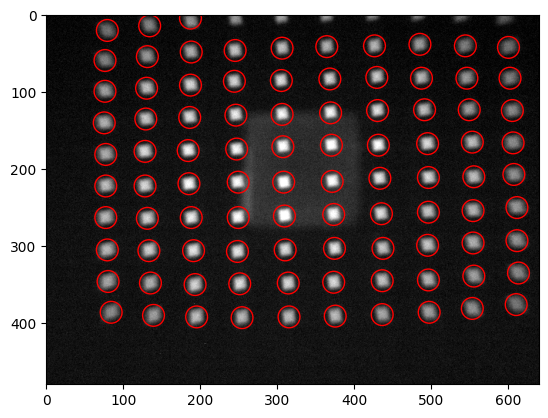

  Processing Pos2.exr …


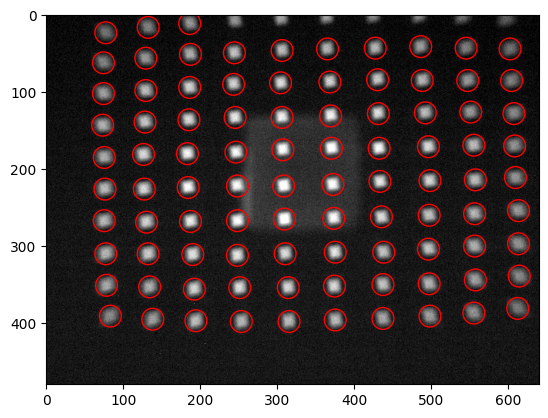

  Processing Pos3.exr …


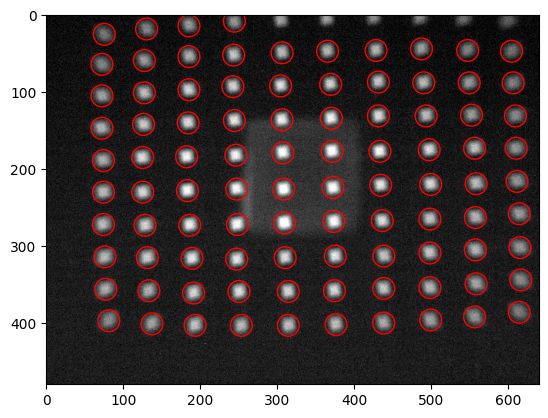

  Processing Pos4.exr …


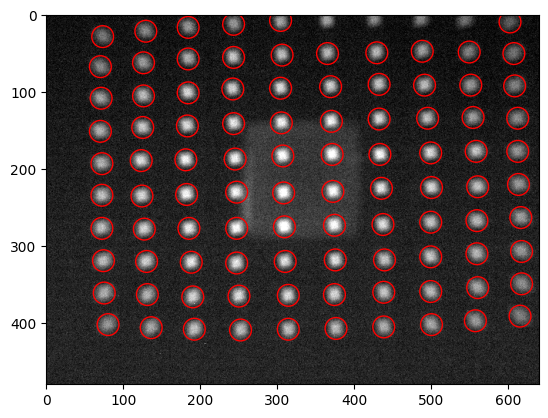

  Processing Pos5.exr …


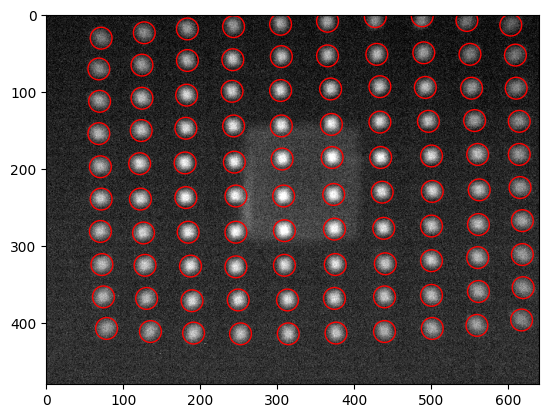

  Processing Pos6.exr …


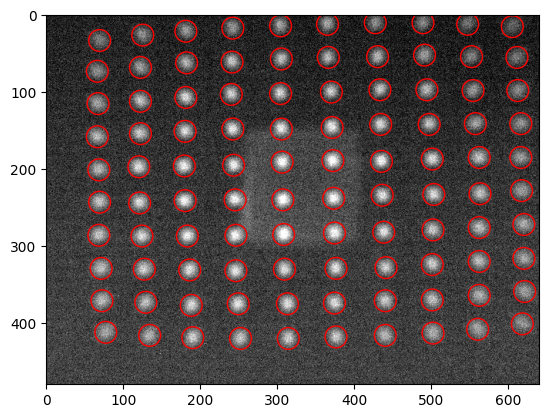

  Processing Pos7.exr …


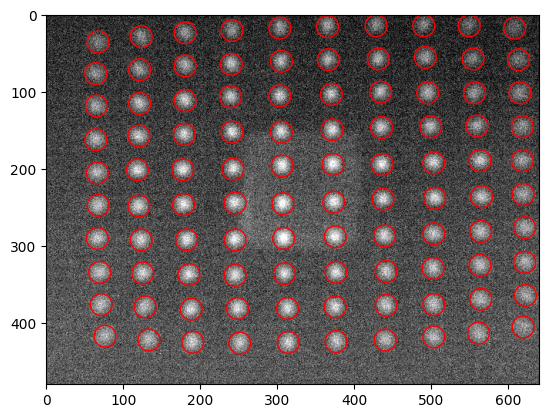

  Processing Pos8.exr …


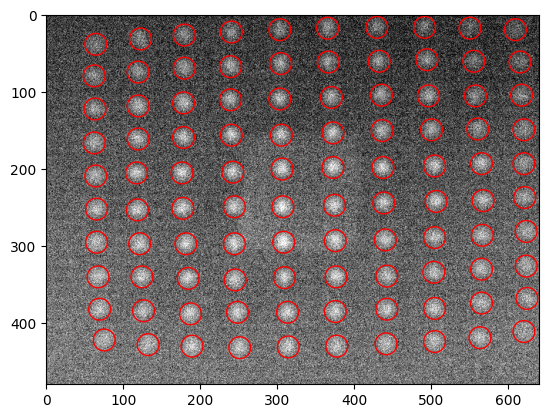

  Processing Pos9.exr …


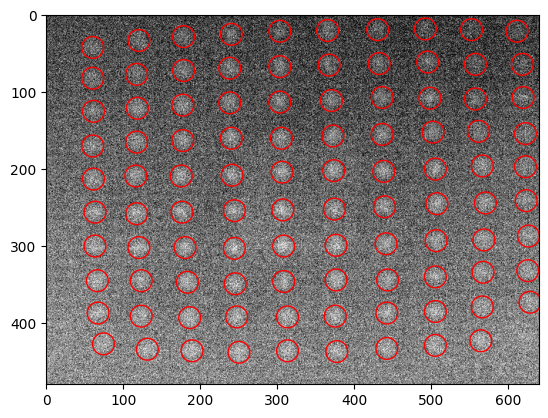


Dots per distance (raw, no grid enforced): [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]
Tracked roster size: 100 dots
IDed dots per distance: [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]


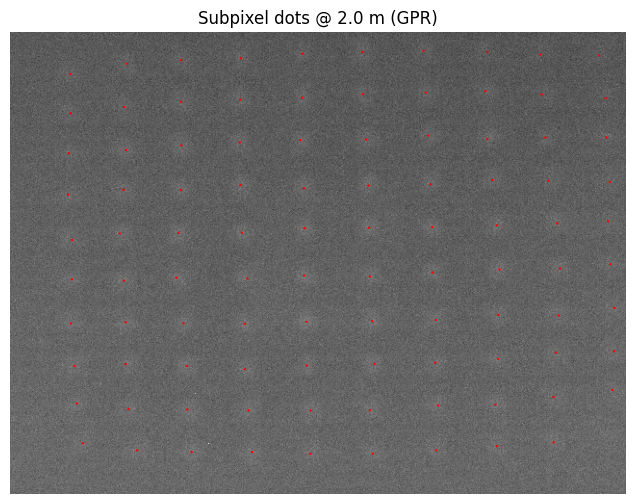

In [40]:
# Collect calibration PCD paths sorted by distance. Pattern and any excluded
# frames come from calibrate.CAMERAS (e.g. Pos9 @3.8 m unwraps wrongly).
EXCLUDE = set(cfg.get("exclude", ()))
pcd_files = sorted(
    (p for p in tof_cal.glob(cfg.get("pcd_glob", "ToF_*m.pcd"))
     if p.stem not in EXCLUDE),
    key=lambda p: calibrate.distance_for(cfg, dotCal, p) or 999.0
)

tof_paths = [str(p) for p in pcd_files]
cal_dists = [calibrate.distance_for(cfg, dotCal, p) for p in tof_paths]
print(f"Calibration distances: {cal_dists}")

# ── Steps 1+2: LoG blob detection + GPR subpixel refinement ─────────────
subpixel_list_unordered = []
for tof_p in tof_paths:
    sl_p = calibrate.find_sl_image(sl_cal, Path(tof_p).name)
    print(f"  Processing {Path(sl_p).name} …")
    blobs, image = dotCal.detect_blobs(str(sl_p), visualize=True, **CAL_BLOB_PARAMS)
    _, subpixels = dotCal.detect_subpixel_locations(blobs, image, mode=SUBPIXEL_MODE)
    subpixel_list_unordered.append(subpixels)

print(f"\nDots per distance (raw, no grid enforced): "
      f"{[len(s) for s in subpixel_list_unordered]}")

# ── Step 2b: cross-distance NN tracking -> stable IDs (Godbaz 4.1) ────────
subpixel_list = dotCal.track_dots_across_distances(
    subpixel_list_unordered, ref_idx=0, threshold_factor=0.5)

n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
print(f"Tracked roster size: {n_dots} dots")
print(f"IDed dots per distance: {[len(s) for s in subpixel_list]}")

# ── Visualize last calibration distance ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap="gray", alpha=0.8)
for d in subpixel_list[-1]:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 0.5,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title(f"Subpixel dots @ {cal_dists[-1]} m ({SUBPIXEL_MODE})")
ax.axis("off")
calibration_figures.append(("step1_2_subpixel_dots", fig))
plt.show()

## Calibration Step 2c: X/Y Travel-Mode Detection

Detecting if the baseline travels in the x or y direction. (Simulatin: X, Real: Y)

With *TRACK_IN_TX_SPACE = True* the dots are re-tracked in the (approximately parallax
invariant) transmitter space using the derived baseline guess, as in the paper.

In [41]:
mode_info = dotCal.detect_travel_mode(subpixel_list, cal_dists, K)
mode = mode_info["mode"]
B_guess_vec = mode_info["B_guess_vec"]
print(f"Travel mode: {mode}")
print(f"du/dw = {mode_info['du_dw']:.2f} px·m,  dv/dw = {mode_info['dv_dw']:.2f} px·m")
print(f"Signed baseline estimate along {mode}: {mode_info['B_axis_est']*100:.3f} cm")
print(f"Signed baseline estimate along z: {mode_info['B_z_est']*100:.3f} cm "
      f"(from {mode_info['n_fit']} dots)")
print(f"B_guess_vec = {B_guess_vec}")

if TRACK_IN_TX_SPACE:
    coords_list = dotCal.tx_space_coords(
        subpixel_list_unordered, tof_paths, K=K, baseline_guess=B_guess_vec)
    subpixel_list = dotCal.track_dots_across_distances(
        subpixel_list_unordered, ref_idx=0, threshold_factor=0.5,
        coords_list=coords_list, travel_mode=mode)
    n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
    print(f"Re-tracked in transmitter space: roster {n_dots} dots")

Travel mode: y
du/dw = 0.14 px·m,  dv/dw = -18.92 px·m
Signed baseline estimate along y: -3.760 cm
Signed baseline estimate along z: 3.139 cm (from 100 dots)
B_guess_vec = [ 0.00083253 -0.03760109  0.0313942 ]


## Calibration Step 3: 3-D Back-Projection

For each detected dot at pixel (u, v), the iToF measurement is sampled
bilinearly to obtain the 3-D point U_ij in camera coordinates; U_tx = U − B_guess.

U shape:    (100, 10, 3)     (n_dots × n_dist × xyz)
U_tx shape: (100, 10, 3)  (shifted by B_guess = [ 0.00083253 -0.03760109  0.0313942 ])


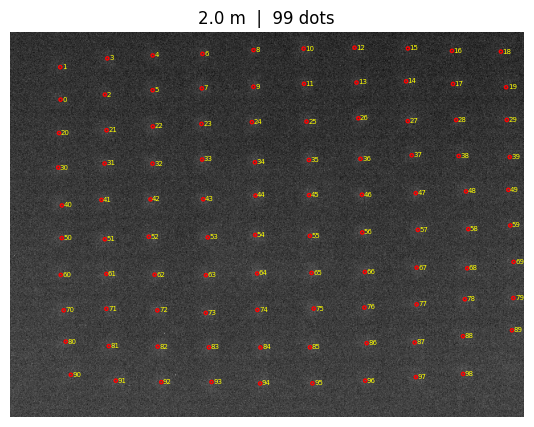

In [42]:
U, U_tx = dotCal.backproject_calibration_dots(
    subpixel_list, tof_paths, K=K,
    pcd_depth_mode="radial",
    baseline_guess=B_guess_vec,
    tof_sample=TOF_SAMPLE,       # "annulus" on the real rig: the projector is on
)                                # during the ToF capture and saturates the dots
print(f"U shape:    {U.shape}     (n_dots × n_dist × xyz)")
print(f"U_tx shape: {U_tx.shape}  (shifted by B_guess = {B_guess_vec})")

# ── Plot: dot IDs at the farthest distance ─────────────────────────────
sl_far = calibrate.find_sl_image(sl_cal, Path(tof_paths[-1]).name)
img = dotCal.read_image(str(sl_far))
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(img, cmap="gray")
for dot in subpixel_list[-1]:
    ax.add_patch(plt.Circle((dot["x"], dot["y"]), 2,
                            edgecolor="red", facecolor="none", linewidth=1))
    ax.text(dot["x"] + 2, dot["y"] + 2, str(dot["id"]),
            fontsize=5, color="yellow")
ax.set_title(f"{cal_dists[-1]} m  |  {len(subpixel_list[-1])} dots")
ax.axis("off")
calibration_figures.append((f"step3_dotids_{cal_dists[-1]}m", fig))
plt.show()

## Calibration Step 4: Baseline Estimation (full 3-D)

Fit a 3D line through each dots calibration distance (in U_tx space), then find
the least-squares intersection of all lines. The full 3D intersection in the origin corrects the
initial guess: `B = B_guess + intersection`.

Multi-stage outlier removal (Godbaz 4.1): dots observed at fewer than `MIN_TRACK_POINTS`
distances contribute no line. With `BASELINE_OUTLIER_SIGMA` set, outlier rays are removed
before the final fit ("After removing outlier rays, the baseline AB is found by an
additional least squares optimization").

Fitted 93 dot lines (after outlier removal)
LS intersection (U_tx):  [ 0.00010563 -0.00062015  0.0015941 ]
B = [ 0.00093817 -0.03822125  0.0329883 ]   (AB along y: -3.8221 cm)


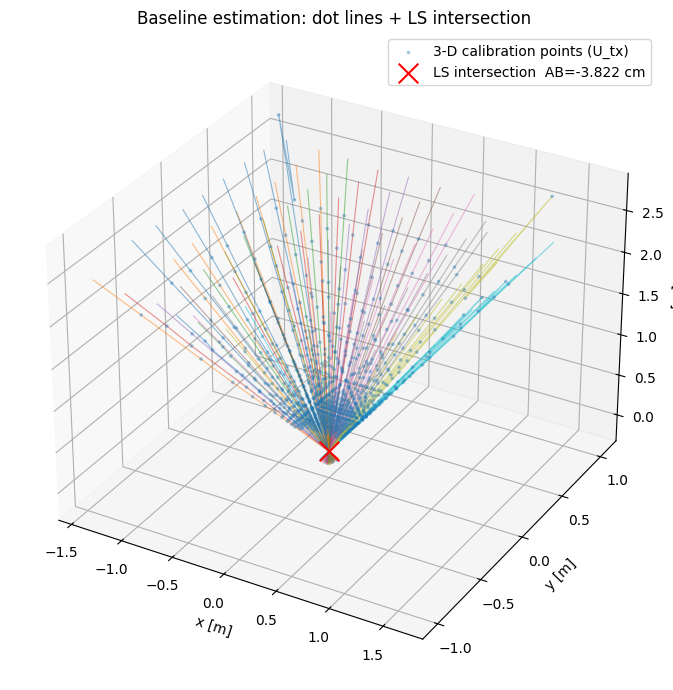

In [43]:
intersection, n_lines = dotCal.estimate_baseline(
    U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA, min_points=MIN_TRACK_POINTS)

B  = B_guess_vec + intersection
axis = 0 if mode == "x" else 1
AB = float(B[axis])

print(f"Fitted {n_lines} dot lines (after outlier removal)")
print(f"LS intersection (U_tx):  {intersection}")
print(f"B = {B}   (AB along {mode}: {AB*100:.4f} cm)")

# ── 3-D plot: points + lines + intersection ─────────────────────────────
all_pts = U_tx.reshape(-1, 3)
all_pts = all_pts[np.all(np.isfinite(all_pts), axis=1)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
           s=3, alpha=0.3, label="3-D calibration points (U_tx)")
cmap = plt.cm.tab10
for i in range(U_tx.shape[0]):
    pts = U_tx[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    if valid.sum() < 2:
        continue
    pts_v = pts[valid]
    direction = pts_v[-1] - pts_v[0]
    extended = np.vstack([(pts_v[0] - 0.3 * direction)[None, :], pts_v,
                          (pts_v[-1] + 0.3 * direction)[None, :]])
    ax.plot(extended[:, 0], extended[:, 1], extended[:, 2],
            color=cmap(i % 10), alpha=0.5, linewidth=0.8)
ax.scatter(*intersection, s=200, marker="x", color="red",
           label=f"LS intersection  AB={AB*100:.3f} cm")
ax.set_title("Baseline estimation: dot lines + LS intersection")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step4_baseline_3d", fig))
plt.show()

## Calibration Step 5: Unit Vector Estimation

For each dot i, fit a unit direction vector V[i] by minimising the angle between
the fitted ray and each calibration point Q_ij = U_ij − B (dots entering/leaving the FOV still get a V).

Unit vectors estimated: 100 / 100


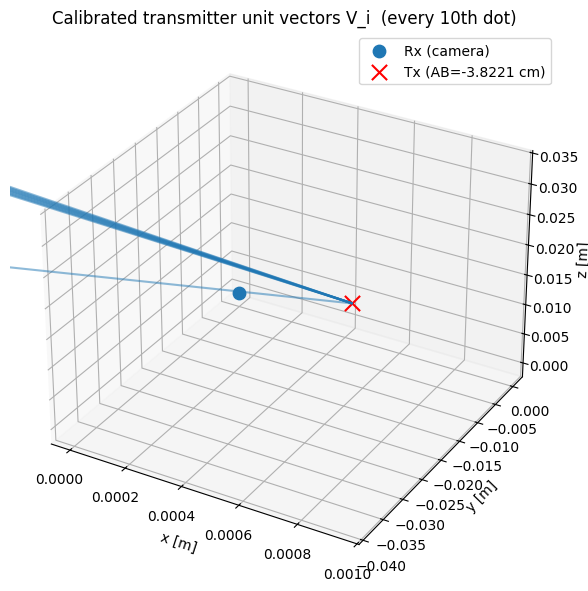

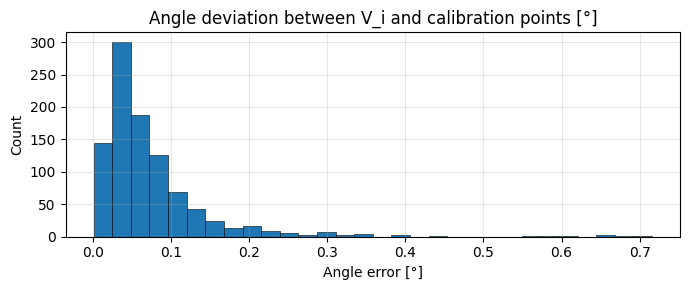

Median angle error: 0.05366°
Max angle error:    0.71584°


In [44]:
V = dotCal.estimate_unit_vectors(U, B)
V_valid = V[np.all(np.isfinite(V), axis=1)]
print(f"Unit vectors estimated: {len(V_valid)} / {V.shape[0]}")

angle_errs = []
for i in range(V.shape[0]):
    if not np.all(np.isfinite(V[i])):
        continue
    pts   = U[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    Q     = pts[valid] - B[None, :]
    Qn    = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    angle_errs.extend(np.degrees(np.arccos(np.clip(Qn @ V[i], -1, 1))).tolist())

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter([0], [0], [0], s=80, marker="o", label="Rx (camera)")
ax.scatter([B[0]], [B[1]], [B[2]], s=120, marker="x", color="red",
           label=f"Tx (AB={AB*100:.4f} cm)")
for i in range(0, V.shape[0], 10):
    if not np.all(np.isfinite(V[i])):
        continue
    ax.quiver(B[0], B[1], B[2], V[i, 0], V[i, 1], V[i, 2],
              length=0.4, normalize=True, alpha=0.5)
ax.set_title("Calibrated transmitter unit vectors V_i  (every 10th dot)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step5_unit_vectors", fig))
plt.show()

plt.figure(figsize=(7, 3))
plt.hist(np.array(angle_errs), bins=30, edgecolor="k", linewidth=0.4)
plt.title("Angle deviation between V_i and calibration points [°]")
plt.xlabel("Angle error [°]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout()
calibration_figures.append(("step5_angle_error_hist", plt.gcf()))
plt.show()

print(f"Median angle error: {np.median(angle_errs):.5f}°")
print(f"Max angle error:    {np.max(angle_errs):.5f}°")

## Calibration Step 6: 1-D Dot Trails + Noise Estimates

The dot trails are precomputed as 1D Vector (Godbaz 4.2).

Calibration also measures the noise levels used by Approach 2:
- **σ_u** [px]: residual of all detections to their trail line
- **σ_ToF(z)**: robust std of the dots ToF depths per distance

Trails: 100 dots, 50 samples on average (z: 0.4 m -> ∞)
sigma_u (2-D cal residual) = 0.2427 px
sigma_u_ab (1-D runtime AB) = 0.3447 px
sigma_ToF(z):
  z = 0.402 m  ->  σ = 5.75 mm
  z = 0.437 m  ->  σ = 5.49 mm
  z = 0.482 m  ->  σ = 4.95 mm
  z = 0.539 m  ->  σ = 4.75 mm
  z = 0.612 m  ->  σ = 5.12 mm
  z = 0.709 m  ->  σ = 7.43 mm
  z = 0.851 m  ->  σ = 6.92 mm
  z = 1.052 m  ->  σ = 9.49 mm
  z = 1.378 m  ->  σ = 15.43 mm
  z = 1.993 m  ->  σ = 19.15 mm


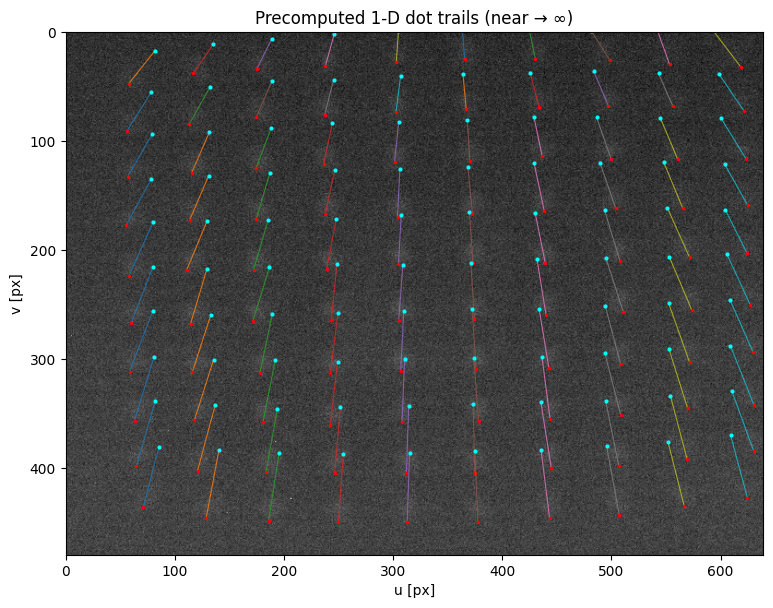

In [45]:
image_shape = image.shape[:2]
TRAIL_Z_MIN = 0.4  # trails run from here to infinity [m] (Godbaz: ~30 cm)
trails = dotCal.fit_trails_from_detections(
    subpixel_list, U, z_min=TRAIL_Z_MIN, step_px=1.0,
    image_shape=image_shape, V=V, B=B, K=K)
n_trails = sum(1 for t in trails if t is not None)
lens = [len(t["u"]) for t in trails if t is not None]
print(f"Trails: {n_trails} dots, {int(np.mean(lens))} samples on average "
      f"(z: {TRAIL_Z_MIN} m -> ∞)")

sigma_u = dotCal.estimate_sigma_u_trails(subpixel_list, trails)
sigma_tof_table = dotCal.estimate_sigma_tof(U, expected_z=cal_dists)
sl_paths = [calibrate.find_sl_image(sl_cal, Path(p).name) for p in tof_paths]
sigma_u_ab = calibrate.estimate_sigma_u_ab(dotCal, subpixel_list, trails, sl_paths, TRAIL_Z_MIN)
print(f"sigma_u (2-D cal residual) = {sigma_u:.4f} px")
print(f"sigma_u_ab (1-D runtime AB) = {sigma_u_ab:.4f} px")
print("sigma_ToF(z):")
for z, s in sigma_tof_table:
    print(f"  z = {z:.3f} m  ->  σ = {s*1e3:.2f} mm")

# ── Trail visualization 
fig = dotCal.plot_dot_trails(trails, image_shape=image_shape, background=image)
calibration_figures.append(("step6_dot_trails", fig))
plt.show()

## Save Calibration

Writes the extended `calibration.json` (incl. mode, full 3-D B, precomputed trails,
σ_u, σ_ToF table) to `Calibrations/<CAL_NAME>/`. Set `CAL_NAME`/`SAVE_PLOTS` below.

In [ ]:
import json as _json
from datetime import datetime as _dt

CAL_NAME   = f"{CAMERA}_paperlike{SOR_TAG}"   # -> Calibrations/<CAL_NAME>/calibration.json
                                              # SOR_TAG keeps a filtered calibration
                                              # beside the unfiltered one instead of
                                              # overwriting it
SAVE_PLOTS = True

cal_dir = Path.cwd().parent / "Calibrations" / CAL_NAME
cal_dir.mkdir(parents=True, exist_ok=True)

cal_data = calibrate.sanitize({
    "metadata": {
        "created": _dt.now().isoformat(),
        "camera": CAMERA,
        "sl_cal_path": str(sl_cal),
        "tof_cal_path": str(tof_cal),
        "pipeline": "codePaperlike",
        "mode": mode,
        "baseline_guess": B_guess_vec.tolist(),
        "subpixel_mode": SUBPIXEL_MODE,
        "pcd_depth_mode": "radial",
        "tof_sample": TOF_SAMPLE,
        "pcd_unit_scale": 0.001,
        "track_in_tx_space": TRACK_IN_TX_SPACE,
        "baseline_outlier_sigma": BASELINE_OUTLIER_SIGMA,
        "baseline_min_points": MIN_TRACK_POINTS,
        "trail_z_min": TRAIL_Z_MIN,
        "sor": {"enabled": bool(SOR_ENABLED), "k": int(SOR_K),
                "nsigma": float(SOR_NSIGMA)},
        "fx": float(fx), "fy": float(fy),
        "cx": float(cx), "cy": float(cy),
    },
    "mode": mode,
    "K": K.tolist(),
    "K_inv": K_inv.tolist(),
    "V": V.tolist(),
    "B": B.tolist(),
    "AB": AB,
    "BASELINE_GUESS": B_guess_vec.tolist(),
    "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "U": U.tolist(),
    "trails": [None if t is None else
               {"u": t["u"].tolist(), "v": t["v"].tolist(), "w": t["w"].tolist()}
               for t in trails],
    "sigma_u": float(sigma_u),
    "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table.tolist(),
})

cal_file = cal_dir / "calibration.json"
with open(cal_file, "w") as f:
    _json.dump(cal_data, f)
print(f"Calibration saved to {cal_file}")

if SAVE_PLOTS:
    for name, fig in calibration_figures:
        fig.savefig(str(cal_dir / f"{name}.png"), dpi=150, bbox_inches="tight")
    print(f"Saved {len(calibration_figures)} plot(s) to {cal_dir}")

## Test Scene Setup

Load a test scene and the precomputed trails.

Ground-truth distance: 1.0 m
Trails: 100 / 100 dots calibrated (mode: y)


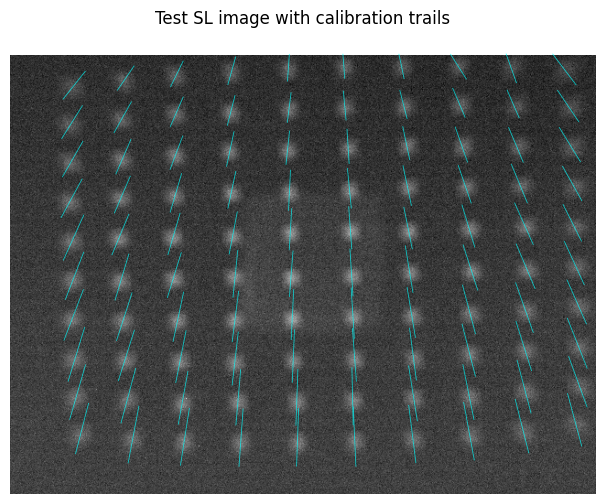

SOR on the test frame (1.00m.pcd): 307200 points, 234956 with a ToF return
  kept 194515, rejected 40441 (17.2% of the valid points)   |   max mean-6NN distance = 22.46 mm


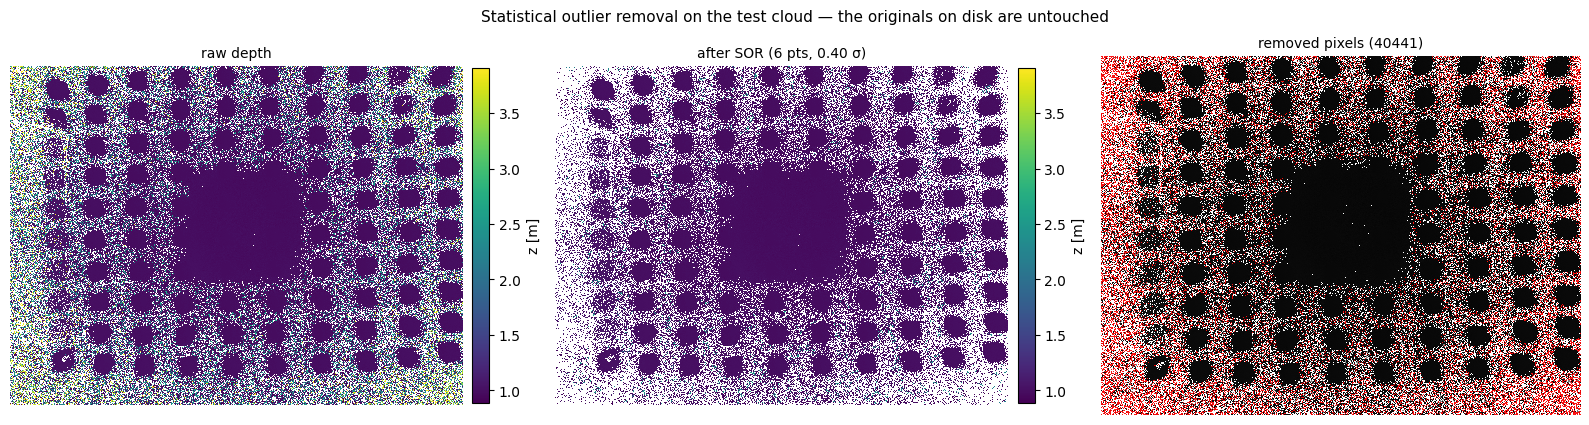

In [72]:
suffix = "_On" if CAMERA == "OnSemi" else "_Schm"
#test_dir = Path(r"C:\Users\Julian\Documents\GitHub\iToF-SL-Combination\Pictures\Test\19.08")
test_dir = Path("/home/julian/Documents/Github/iToF-SL-Combination/Pictures/Test/FlatWallSchmersalReal")
#test_dir = Path("/Users/julian/Documents/Github/iToF-SL-Combination/Pictures/Test/FlatWallSchmersalReal")
SL_TEST  = str(test_dir / f"1.00m.exr")
TOF_TEST = str(test_dir / f"1.00m.pcd")

# Ground truth from filename (e.g. "SL_0.81m.png" -> 0.81m)
approaches.GT_DISTANCE = approaches._parse_gt_distance(SL_TEST)
offset = 0
approaches.GT_DISTANCE = approaches.GT_DISTANCE-offset
print(f"Ground-truth distance: {approaches.GT_DISTANCE} m")

# Calibration dict
cal = {
    "K": K, "K_inv": K_inv, "V": V, "B": B,
    "AB": AB, "mode": mode,
    "U": U, "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "trails": trails,
    "sigma_u": float(sigma_u), "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table,
    "metadata": {"pcd_unit_scale": 0.001, "trail_z_min": TRAIL_Z_MIN, "mode": mode},
}

setup = approaches.common_setup(dotCal, cal, SL_TEST, TOF_TEST)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(setup["sl_gray"], cmap="gray")
for t in setup["trails"]:
    if t is not None:
        ax.plot(t["u"], t["v"], lw=0.6, alpha=0.7, color="cyan")
ax.set_title("Test SL image with calibration trails"); ax.axis("off"); plt.show()

# ── What did SOR remove from this test frame? ────────────────────────────────
# common_setup above already ran on the filtered cloud; this only makes the
# difference visible at the place you actually look at it.
if not SOR_ENABLED:
    print("SOR disabled — the test frame is the raw cloud.")
else:
    _raw = _sor_orig_load_tof_pcd(dotCal, TOF_TEST, unit_scale=0.001, depth_mode="axial")
    _fil = dotCal.load_tof_pcd(TOF_TEST, unit_scale=0.001, depth_mode="axial")
    _kr = np.isfinite(_raw["distance"])
    _kf = np.isfinite(_fil["distance"])
    _thr = sor_keep_mask(_raw["points_3d"])[1]
    print(f"SOR on the test frame ({Path(TOF_TEST).name}): {len(_kr)} points, "
          f"{_kr.sum()} with a ToF return")
    print(f"  kept {_kf.sum()}, rejected {_kr.sum() - _kf.sum()} "
          f"({100.0 * (_kr.sum() - _kf.sum()) / max(_kr.sum(), 1):.1f}% of the valid points)"
          f"   |   max mean-{SOR_K}NN distance = {_thr * 1e3:.2f} mm")

    _dr, _df = _raw["depth_map"], _fil["depth_map"]
    _lo, _hi = np.nanpercentile(_dr[np.isfinite(_dr)], [1, 99])
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.4))
    for _ax, _img, _ttl in ((axs[0], _dr, "raw depth"),
                            (axs[1], _df, f"after SOR ({SOR_K} pts, {SOR_NSIGMA:.2f} σ)")):
        _im = _ax.imshow(_img, cmap="viridis", vmin=_lo, vmax=_hi, interpolation="nearest")
        _ax.set_title(_ttl, fontsize=10)
        _ax.axis("off")
        fig.colorbar(_im, ax=_ax, fraction=0.035, pad=0.02, label="z [m]")
    _removed = np.isfinite(_dr) & ~np.isfinite(_df)
    axs[2].imshow(_dr, cmap="gray", vmin=_lo, vmax=_hi, interpolation="nearest")
    axs[2].imshow(np.ma.masked_where(~_removed, _removed), cmap="autumn",
                  interpolation="nearest", alpha=0.9)
    axs[2].set_title(f"removed pixels ({_removed.sum()})", fontsize=10)
    axs[2].axis("off")
    fig.suptitle("Statistical outlier removal on the test cloud — the originals on "
                 "disk are untouched", fontsize=11)
    fig.tight_layout()
    plt.show()


## Approach 1: Consistency Error  (Microsoft-Paper §4.2)

Pure trail scan, no dot localisation, no runtime triangulation. For every calibrated dot
trail, the ToF depth image is resampled along the trail. the sample k\* = argmin ε with
**ε = |1/Z_ToF − 1/Z_tri|** (Z_tri precomputed per sample) is selected and the **ToF depth**
at k\* is returned. Dots with ε\* above `approaches.EPS_THRESHOLD` are invalidated.
The reported standard deviation σ (especially meaningful on planar scenes) is printed in the legend of the figures.

Approach 1: scanned 100 trails (0 invalidated by ε-threshold 0.1)
  ε range: 1.638e-04 – 3.365e-02
  Z_out (ToF @ min-ε): n=100/100  mean=0.9941 m  σ=13.40 mm

  ** Approach 1 — Average Error **
     GT distance:  1.0000 m
     Valid dots:   100 / 100
     Mean error:   -0.0059 m
     Mean |error|: 0.0120 m
     Std error:    0.0134 m
     Min error:    -0.0244 m
     Max error:    +0.0447 m
AVG_ERR|1|1.0000|100|100|-0.005876|0.012029|0.013396|-0.024370|0.044672


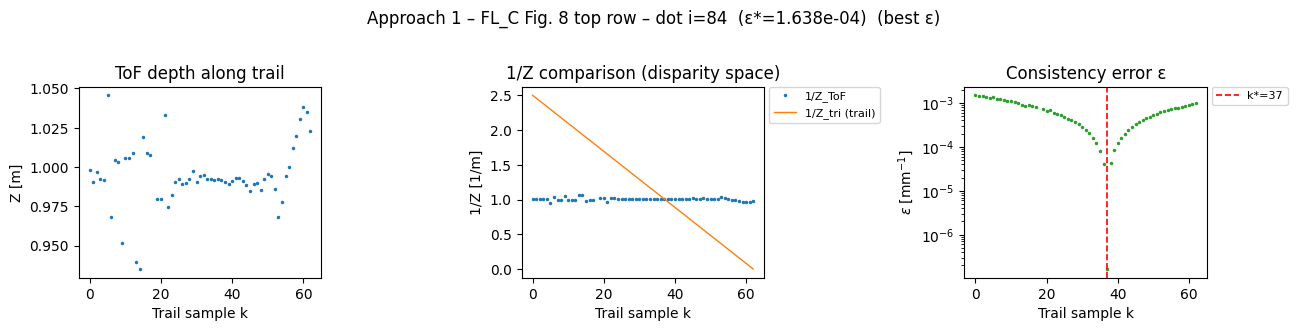

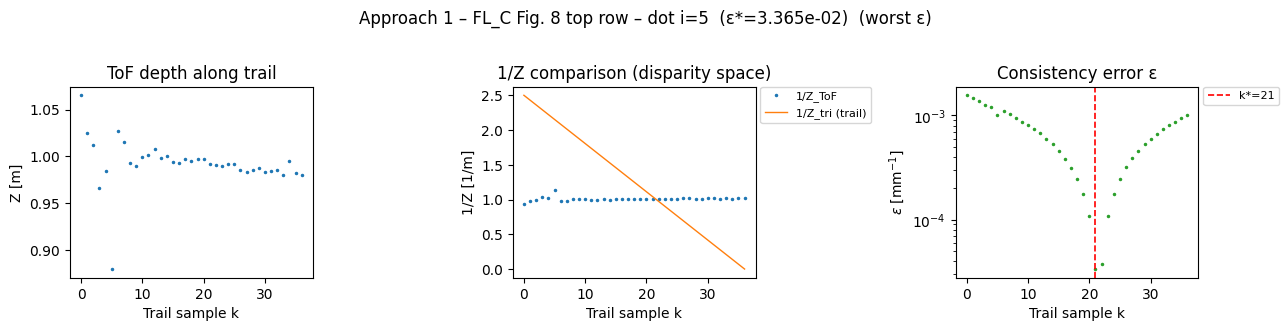

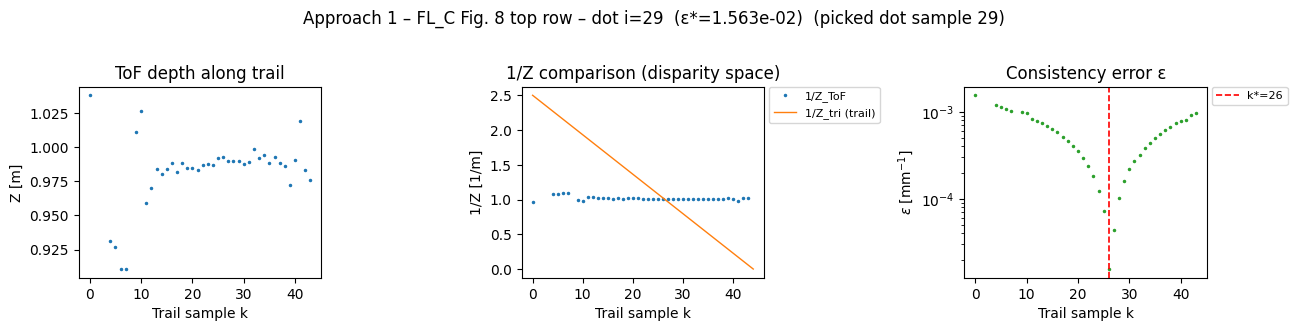

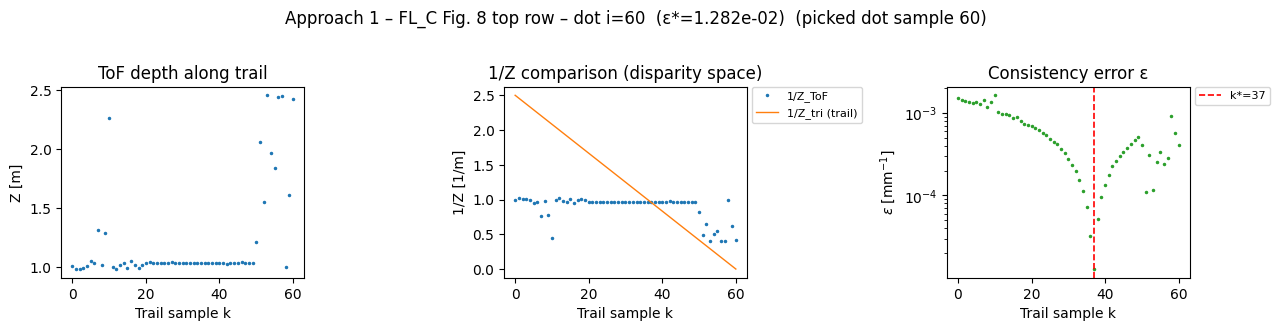

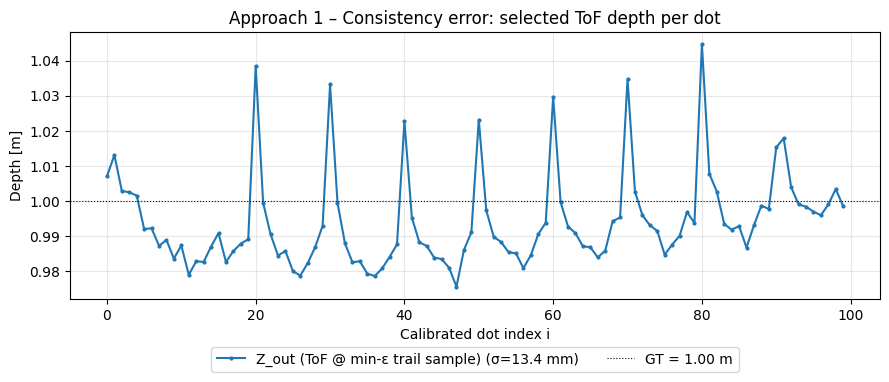

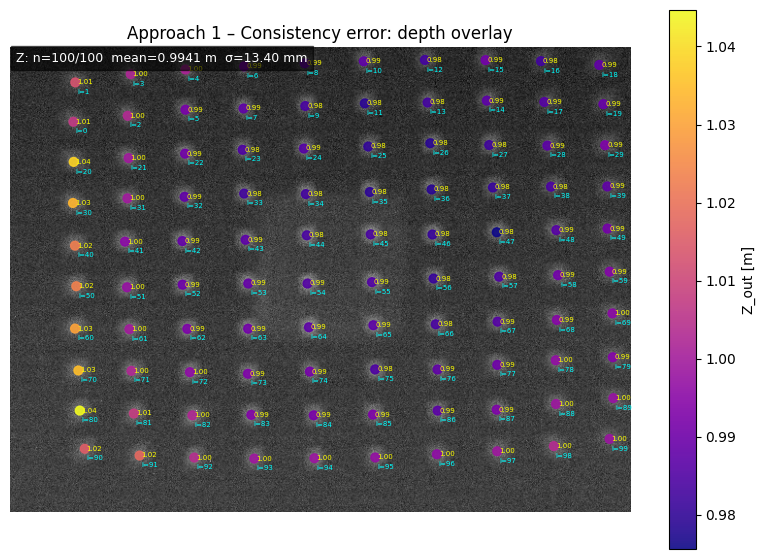

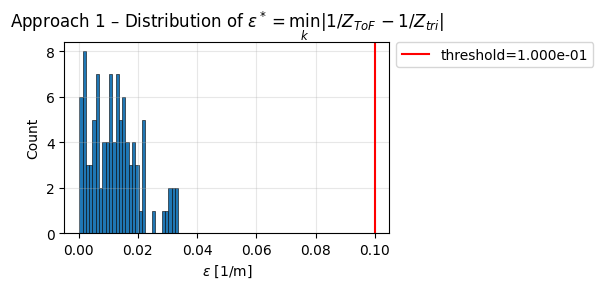

In [73]:


res1 = approaches.run_approach_1(dotCal, cal, setup, make_plots=True,limit=None, dot_sample=[29,60], exclude=[])
approaches.print_average_error(1, res1["depths"])
plt.show()

## Approach 2: Gaussian Maximum-Likelihood Fusion  (Agresti & Zanuttigh)

Dot identfication identical to Approach 3 (AB peaks along the trail -> min-ε with iToF -> quadratic
subpixel -> triangulation). Then each modality is modelled as **one Gaussian**. (Removed 7x7 windowed Gaussian, not needed, because we do not use SL phase information and have exactly one pixel position -> no weighted Gaussian)

- σ_SL = z²/(‖B‖·f)·σ_u  (calibrated σ_u -> Agresti's d⁴/B² variance scaling)
- σ_ToF(z) interpolated from the calibration flat-wall noise table

The joint likelihood is the product of the two Gaussians. The depth at its maximum
(precision-weighted mean) is returned. Standard deviations for **SL, iToF and the joint
estimate** are printed as well.

Approach 2: 100 trails, 97 fused depths
  SL (triangulated): n=100/100  mean=1.0017 m  σ=39.08 mm
  iToF: n=100/100  mean=0.9942 m  σ=13.53 mm
  Joint likelihood: n=97/100  mean=0.9945 m  σ=14.36 mm
  mean predicted σ_SL: 18.18 mm
  mean predicted σ_ToF: 8.75 mm
  mean predicted σ_joint: 7.79 mm

  ** Approach 2 — Average Error **
     GT distance:  1.0000 m
     Valid dots:   97 / 100
     Mean error:   -0.0055 m
     Mean |error|: 0.0125 m
     Std error:    0.0144 m
     Min error:    -0.0296 m
     Max error:    +0.0507 m
AVG_ERR|2|1.0000|97|100|-0.005539|0.012491|0.014364|-0.029616|0.050704


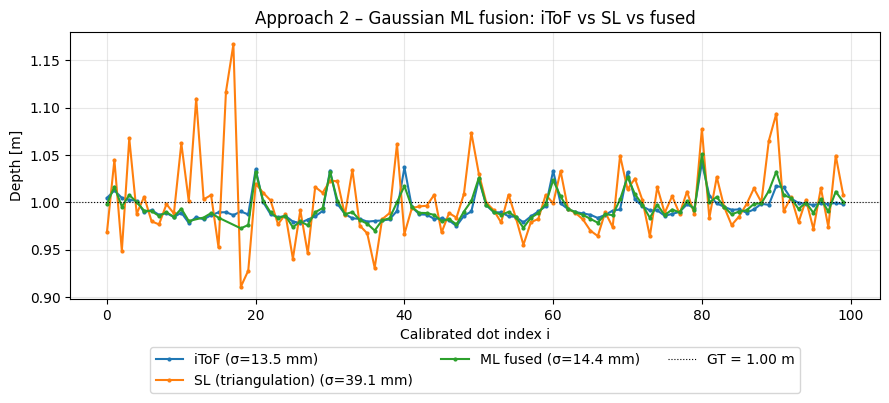

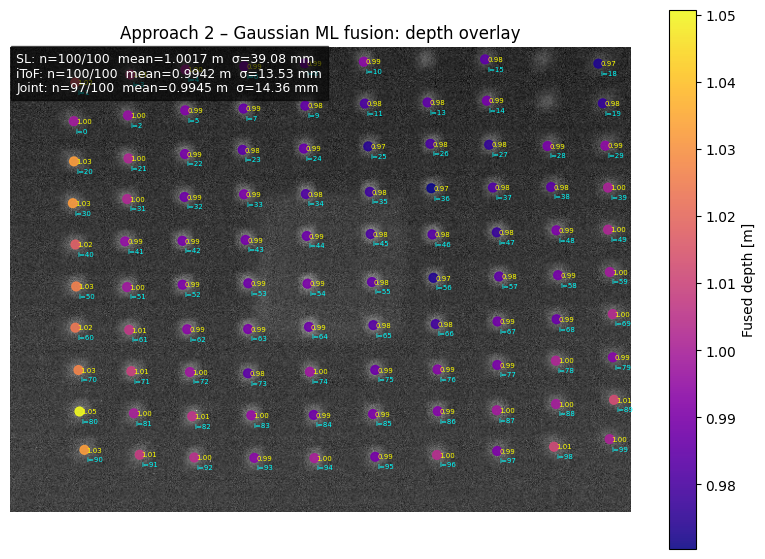

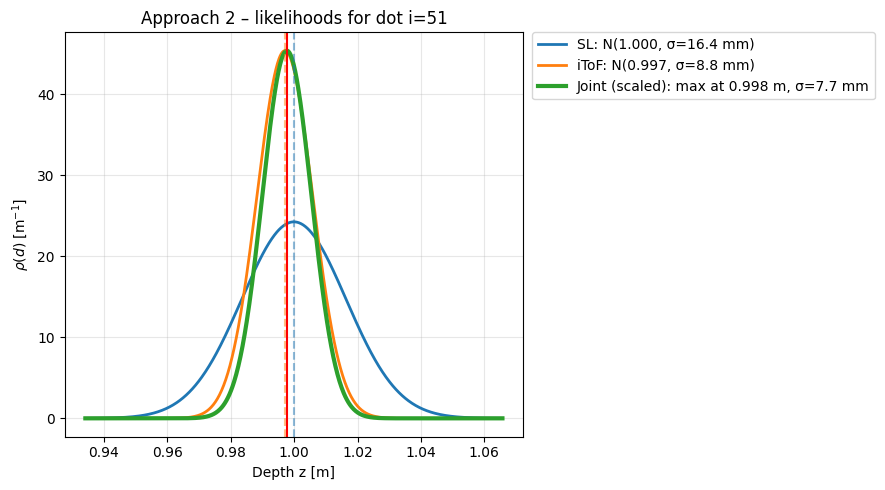

In [74]:
res2 = approaches.run_approach_2(dotCal, cal, setup, make_plots=True, limit = None)
approaches.print_average_error(2, res2["depths"])
plt.show()

## Approach 3: Active Brightness Trail  (Microsoft-Paper §4.2)

1. Resample the active brightness along each dot trail (1-D vector)
2. Peak finding (relative prominence, trails intersect, multiple peaks expected)
3. Select the peak minimising ε = |1/Z_ToF − 1/Z_tri| (iToF resolves the ambiguity)
4. Subpixel via a **locally fitted quadratic** on the 1-D AB signal (2D GPR also possible, as Godbaz states in the paper)
5. Return the **triangulated** depth at the refined position.

Approach 3: 100 trails (0 without AB peaks, 3 invalid after ε-gate)
  Z_out (triangulated): n=97/100  mean=0.9977 m  σ=31.99 mm

  ** Approach 3 — Average Error **
     GT distance:  1.0000 m
     Valid dots:   97 / 100
     Mean error:   -0.0023 m
     Mean |error|: 0.0239 m
     Std error:    0.0320 m
     Min error:    -0.0888 m
     Max error:    +0.0935 m
AVG_ERR|3|1.0000|97|100|-0.002309|0.023888|0.031990|-0.088850|0.093479


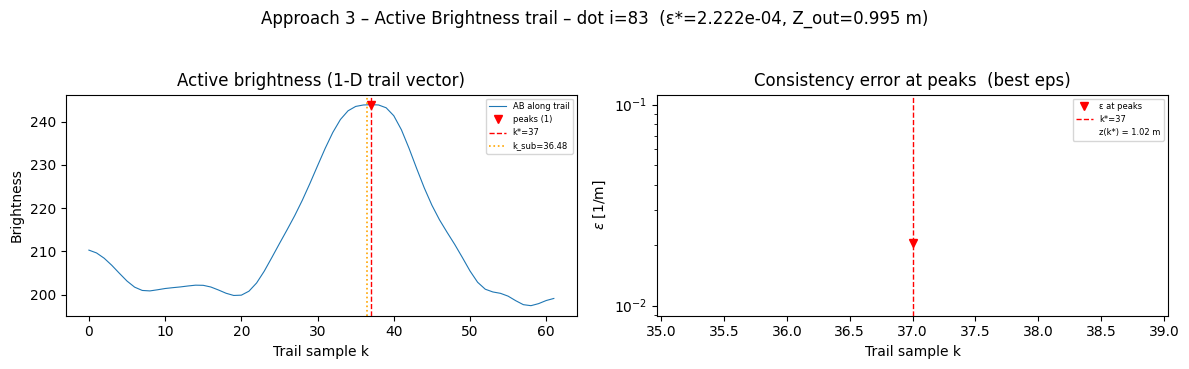

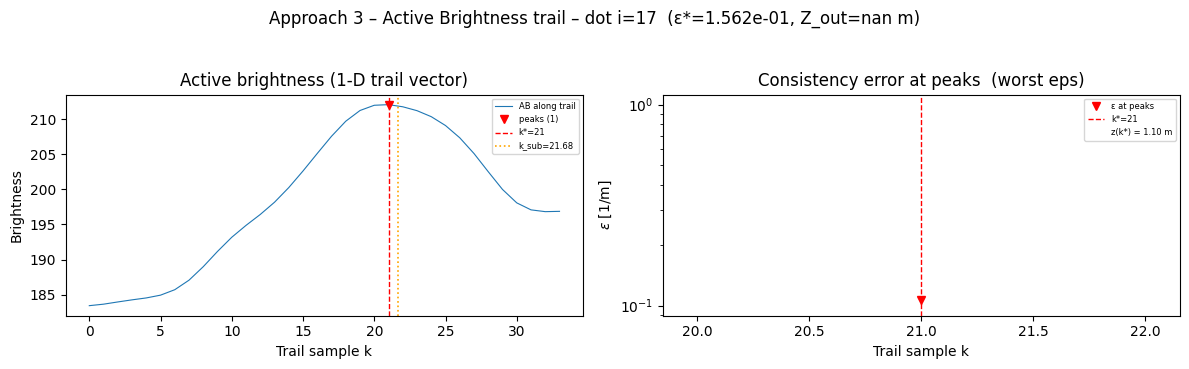

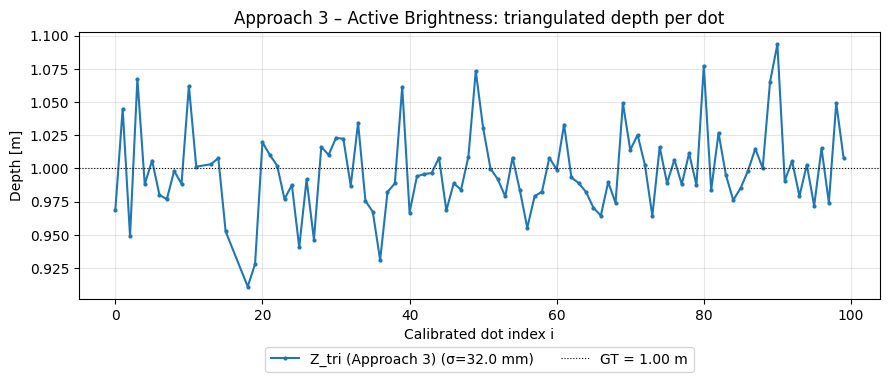

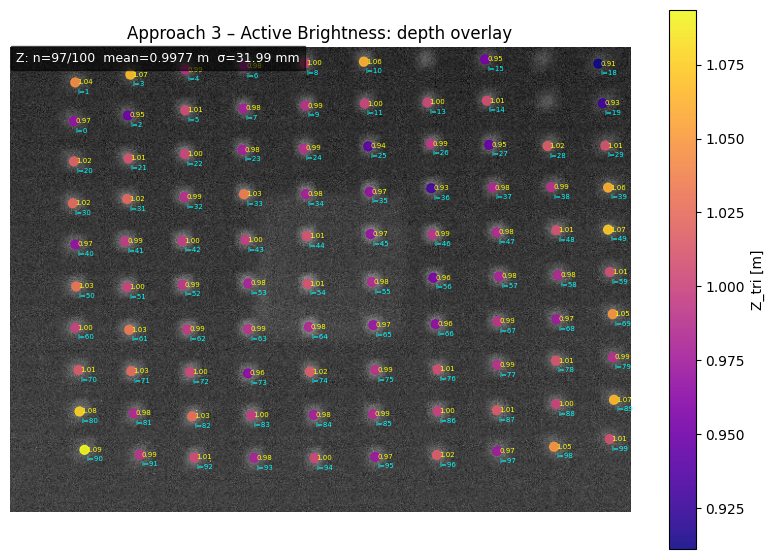

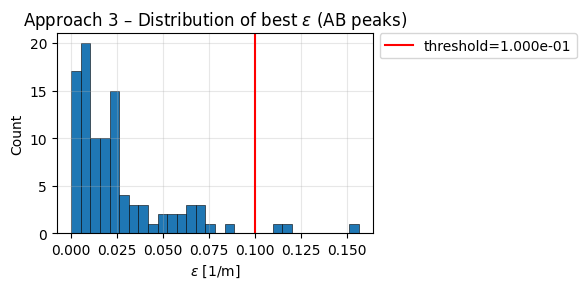

In [75]:

res3 = approaches.run_approach_3(dotCal, cal, setup, make_plots=True,limit=None)
approaches.print_average_error(3, res3["depths"])
plt.show()